In [1]:
# CODEALPHA TASK 3: HANDWRITTEN CHARACTER RECOGNITION
# USING CNN ON MNIST DATASET

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


Loading MNIST Dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


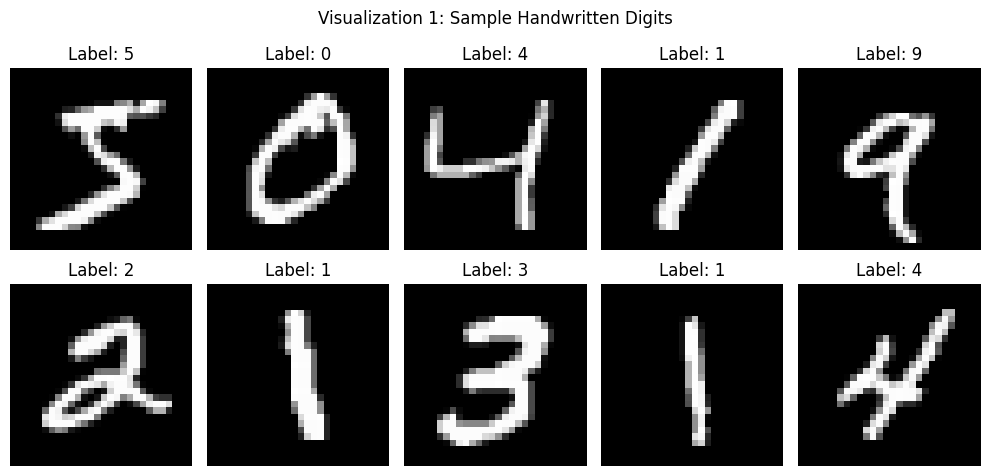

In [2]:
# LOAD DATASET
print("Loading MNIST Dataset...")

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

# VISUALIZATION 1: SAMPLE HANDWRITTEN DIGITS
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Visualization 1: Sample Handwritten Digits")
plt.tight_layout()
plt.show()

In [3]:
# DATA PREPROCESSING
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [4]:
# BUILD CNN MODEL
model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nCNN Model Summary:")
model.summary()

# TRAIN MODEL
print("\nTraining Model...\n")

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)


CNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training Model...

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9602 - loss: 0.1309 - val_accuracy: 0.9849 - val_loss: 0.0451
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9865 - loss: 0.0435 - val_accuracy: 0.9899 - val_loss: 0.0307
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9912 - loss: 0.0283 - val_accuracy: 0.9914 - val_loss: 0.0265
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9933 - loss: 0.0210 - val_accuracy: 0.9904 - val_loss: 0.0295
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9909 - val_loss: 0.0286


In [6]:
#EVALUATE MODEL
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("\n==============================")
print("FINAL RESULTS")
print("==============================")

print("Test Accuracy:",
      round(test_acc * 100, 2),
      "%")

print("Test Loss:",
      round(test_loss, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9909 - loss: 0.0286

FINAL RESULTS
Test Accuracy: 99.09 %
Test Loss: 0.0286


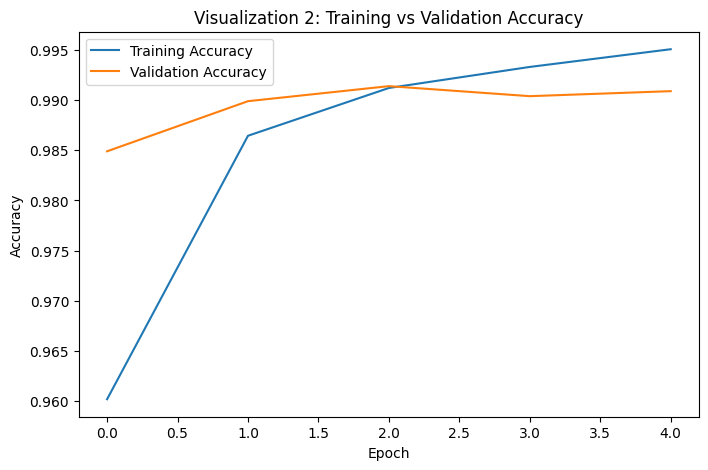

In [7]:
# VISUALIZATION 2:TRAINING vs VALIDATION ACCURACY
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'Visualization 2: Training vs Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

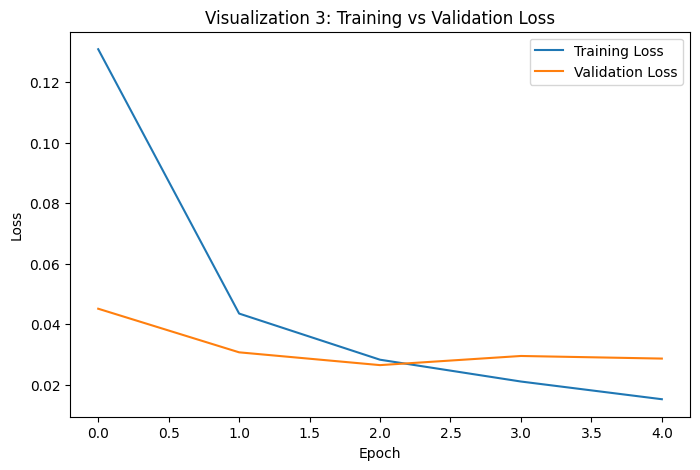

In [8]:
# VISUALIZATION 3:TRAINING vs VALIDATION LOSS
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'Visualization 3: Training vs Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
# PREDICTIONS
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


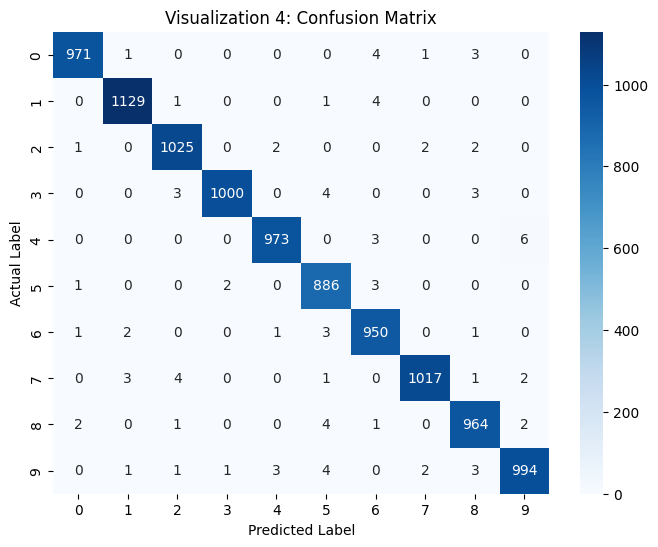

In [10]:
# VISUALIZATION 4:CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Visualization 4: Confusion Matrix'
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [11]:
# CLASSIFICATION REPORT
print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================\n")

print(
    classification_report(
        y_test,
        y_pred_classes
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.98      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



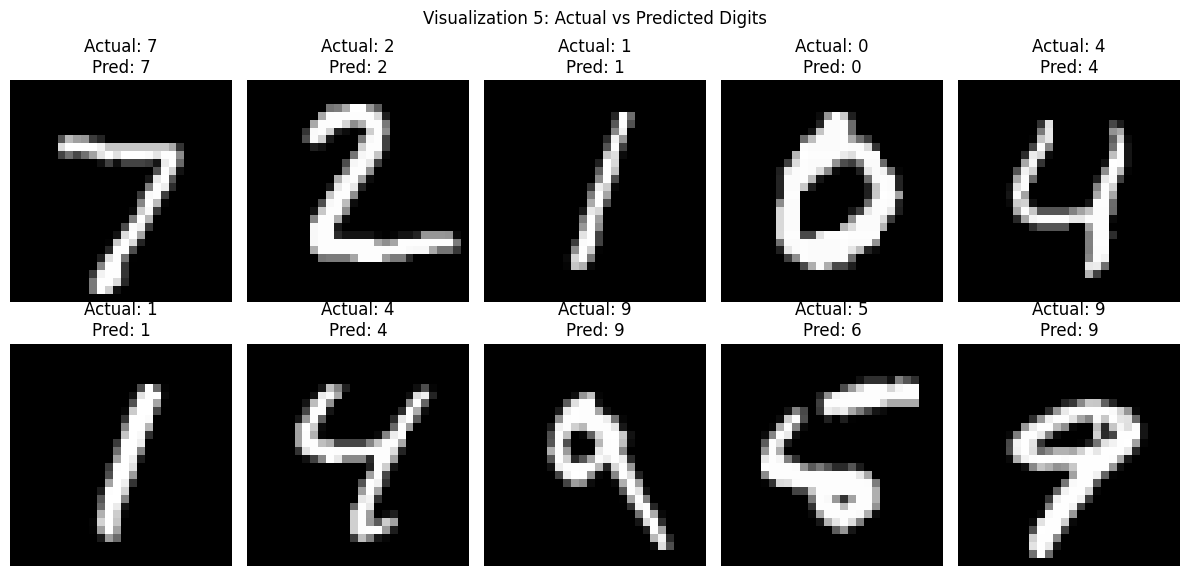

In [12]:
# VISUALIZATION 5:ACTUAL vs PREDICTED DIGITS
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        x_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Actual: {y_test[i]}\nPred: {y_pred_classes[i]}"
    )

    plt.axis('off')

plt.suptitle(
    "Visualization 5: Actual vs Predicted Digits"
)

plt.tight_layout()
plt.show()

In [13]:
#SAVE MODEL
model.save("mnist_cnn_model.h5")
print("\nModel Saved Successfully!")
print("File Name: mnist_cnn_model.h5")
# PROJECT COMPLETE
print("\n======================================")
print("CODEALPHA TASK 3 COMPLETED SUCCESSFULLY")
print("======================================")


Model Saved Successfully!
File Name: mnist_cnn_model.h5

CODEALPHA TASK 3 COMPLETED SUCCESSFULLY


In [14]:
from google.colab import files
files.download("mnist_cnn_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>